# Visualization — Forecast Examples

Loads the trained XGBoost models from `models_final/`, runs them on the test set,
and plots forecast examples for the 3 sunniest and 3 cloudiest days.

**Baselines included:** persistence (flat) and climatology (historical mean).

---
## 1. Setup & Data Loading

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import json
from pathlib import Path

MODEL_DIR = Path("models_final")
DATA_PATH = "clean_jun_v2.csv"
RANDOM_STATE = 42

# Load metadata
with open(MODEL_DIR / 'metadata.json') as f:
    meta = json.load(f)

feature_cols = meta['feature_cols']
horizon_names = meta['horizon_names']
steps = list(range(1, 7))
target_cols = [f'target_solar_diff_{h}' for h in horizon_names]
print(f"Loaded metadata: {len(feature_cols)} features, {len(horizon_names)} horizons")

Loaded metadata: 49 features, 6 horizons


In [8]:
# --- Load and engineer data (same pipeline as training) ---
df_raw = pd.read_csv(DATA_PATH)
df_raw['TIMESTAMP'] = pd.to_datetime(df_raw['TIMESTAMP'])
df_raw = df_raw.set_index('TIMESTAMP').sort_index()

def engineer_features(df, resample_rule='30min'):
    """Resample 15-min station data to 30-min and create features."""
    df = df.copy()
    
    # --- Resample to 30-min means ---
    df = df.resample(resample_rule).mean()
    
    # A. Cyclical time features
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['doy_sin']  = np.sin(2 * np.pi * df.index.dayofyear / 365.25)
    df['doy_cos']  = np.cos(2 * np.pi * df.index.dayofyear / 365.25)

    # B. Velocity & acceleration (ramp mechanics)
    df['v_solar'] = df['solar_kw'].diff()
    df['a_solar'] = df['v_solar'].diff()
    df['solar_volatility_2h'] = df['solar_kw'].rolling(window=4).std()
    
    # C. Environmental interaction
    if 'rh_avg' in df.columns:
        df['v_humidity'] = df['rh_avg'].diff()
        df['humidity_solar_risk'] = (df['rh_avg'] / 100) * (1 - df['solar_kw'])

    # D. Lag memory (6h and 24h) for all physical sensors
    physical_sensors = ['solar_kw', 'net_rad_wm2', 'temp_c', 'rh_avg', 
                        'wind_speed_ms', 'wind_dir', 'rain_mm']
    lag_cols = [c for c in physical_sensors if c in df.columns]
    for col in lag_cols:
        df[f'{col}_lag_6h'] = df[col].shift(12)
        df[f'{col}_lag_24h'] = df[col].shift(48)
        
    # E. 30-min step-by-step history (solar only)
    for i in range(1, 7):
        df[f'solar_lag_{i*30}m'] = df['solar_kw'].shift(i)

    # F. Clear sky proxy
    df['solar_time_ratio'] = df['solar_kw'] / (df['hour_sin'] + 0.1)
    df['solar_time_ratio'] = df['solar_time_ratio'].clip(0, 5)
    
    # G. Wind vectors
    wd_rad = np.radians(df['wind_dir'])
    df['wind_x'] = df['wind_speed_ms'] * np.cos(wd_rad)
    df['wind_y'] = df['wind_speed_ms'] * np.sin(wd_rad)

    # H. Wet ground memory
    if 'leaf_wetness' in df.columns:
        df['wet_ground_lag_6h'] = df['leaf_wetness'].shift(12)

    # I. True 1-hour trend
    df['solar_trend_1h'] = df['solar_kw'] - df['solar_kw'].shift(2)

    return df.dropna()


df = engineer_features(df_raw)
print(f"After feature engineering: {df.shape[0]:,} rows, {df.shape[1]} columns")

# --- Filter + generate targets ---
df_day = df.between_time('6:00', '15:00').copy()
for s in steps:
    df_day[f'target_solar_diff_{s*30}m'] = df_day['solar_kw'].shift(-s) - df_day['solar_kw']
df_day = df_day.dropna()

# --- Split ---
n = len(df_day)
train_end = int(n * 0.8)
train = df_day.iloc[:train_end]
test  = df_day.iloc[train_end:]
print(f"Train: {len(train):,} | Test: {len(test):,}")

After feature engineering: 187,615 rows, 49 columns
Train: 59,398 | Test: 14,850


---
## 2. Load Models & Compute Baselines

In [9]:
# --- Load XGBoost models ---
models = {}
for h in horizon_names:
    fname = MODEL_DIR / f"daylight_{h}.json"
    if not fname.exists():
        print(f"Warning: {fname} not found")
        continue
    m = xgb.XGBRegressor()
    m.load_model(str(fname))
    models[h] = m

print(f"Loaded {len(models)} models: {list(models.keys())}")

Loaded 6 models: ['30m', '60m', '90m', '120m', '150m', '180m']


In [10]:
# --- Compute baseline metrics on the entire test set ---
# XGBoost
def eval_xgb(dataset):
    solar_vals = dataset['solar_kw'].values
    rows = []
    for s, h in zip(steps, horizon_names):
        target = f'target_solar_diff_{h}'
        pred_ramp = models[h].predict(dataset[feature_cols])
        pred_abs = np.clip(solar_vals + pred_ramp, 0, None)
        actual_abs = solar_vals + dataset[target].values
        mask = (~np.isnan(actual_abs)) & (actual_abs > 0.01)
        if mask.sum() == 0: continue
        mae = mean_absolute_error(actual_abs[mask], pred_abs[mask]) * 1000
        rows.append({'model': 'XGBoost', 'horizon': h,
                     'horizon_min': s*30, 'mae_wm2': round(mae, 2)})
    return pd.DataFrame(rows).sort_values('horizon_min')

# Persistence
def eval_persist(dataset):
    solar_vals = dataset['solar_kw'].values
    rows = []
    for s, h in zip(steps, horizon_names):
        target = f'target_solar_diff_{h}'
        actual_abs = solar_vals + dataset[target].values
        mask = (~np.isnan(actual_abs)) & (actual_abs > 0.01)
        if mask.sum() == 0: continue
        mae = mean_absolute_error(actual_abs[mask], solar_vals[mask]) * 1000
        rows.append({'model': 'Persistence', 'horizon': h,
                     'horizon_min': s*30, 'mae_wm2': round(mae, 2)})
    return pd.DataFrame(rows).sort_values('horizon_min')

# Climatology
def eval_clim(dataset, train_set):
    clim = train_set.groupby([train_set.index.hour, train_set.index.minute])['solar_kw'].mean()
    rows = []
    solar_vals = dataset['solar_kw'].values
    for s, h in zip(steps, horizon_names):
        target = f'target_solar_diff_{h}'
        actual_abs = solar_vals + dataset[target].values
        future_times = dataset.index + pd.Timedelta(minutes=s*30)
        clim_vals = np.array([clim.get((t.hour, t.minute), 0) for t in future_times])
        mask = (~np.isnan(actual_abs)) & (actual_abs > 0.01)
        if mask.sum() == 0: continue
        mae = mean_absolute_error(actual_abs[mask], clim_vals[mask]) * 1000
        rows.append({'model': 'Climatology', 'horizon': h,
                     'horizon_min': s*30, 'mae_wm2': round(mae, 2)})
    return pd.DataFrame(rows).sort_values('horizon_min')

eval_xgb_df = eval_xgb(test)
eval_persist_df = eval_persist(test)
eval_clim_df = eval_clim(test, train)

summary = eval_xgb_df[['horizon', 'mae_wm2']].rename(columns={'mae_wm2': 'XGBoost'})
summary['Persistence'] = eval_persist_df['mae_wm2'].values
summary['Climatology'] = eval_clim_df['mae_wm2'].values

print("MAE comparison (W/m²):")
summary

MAE comparison (W/m²):


,horizon,XGBoost,Persistence,Climatology
0,30m,34.57,44.70,80.85
1,60m,45.77,73.80,81.43
2,90m,50.21,99.12,82.82
3,120m,56.56,121.14,85.22
4,150m,58.23,139.07,88.99
5,180m,61.74,153.06,94.02


---
## 3. Select Sunny & Cloudy Days

Sunny = top 3 days with highest mean irradiance in the test set.
Cloudy = bottom 3 days.

In [11]:
# Find best/worst days in the test set
test_dates = test.index.date
daily_mean = test.groupby(test_dates)['solar_kw'].mean().sort_values()

sunny_dates = list(daily_mean.tail(3).index)  # highest mean
cloudy_dates = list(daily_mean.head(3).index)  # lowest mean

print("Sunny days (highest mean solar):")
for d in sunny_dates:
    v = daily_mean[d]
    print(f"  {d}: mean = {v:.3f} kW/m²")

print("\nCloudy days (lowest mean solar):")
for d in cloudy_dates:
    v = daily_mean[d]
    print(f"  {d}: mean = {v:.3f} kW/m²")

Sunny days (highest mean solar):
  2024-04-02: mean = 0.424 kW/m²
  2024-04-01: mean = 0.428 kW/m²
  2024-03-30: mean = 0.429 kW/m²

Cloudy days (lowest mean solar):
  2025-03-26: mean = 0.052 kW/m²
  2025-01-31: mean = 0.055 kW/m²
  2025-01-13: mean = 0.058 kW/m²


---
## 4. Plot Forecast Examples

For each selected day, pick 3 representative times (early, mid, late) in the operational window.
Plots: historical climatology, persistence, XGBoost with confidence fan, and ground truth.

NameError: name 'clim_lookup' is not defined

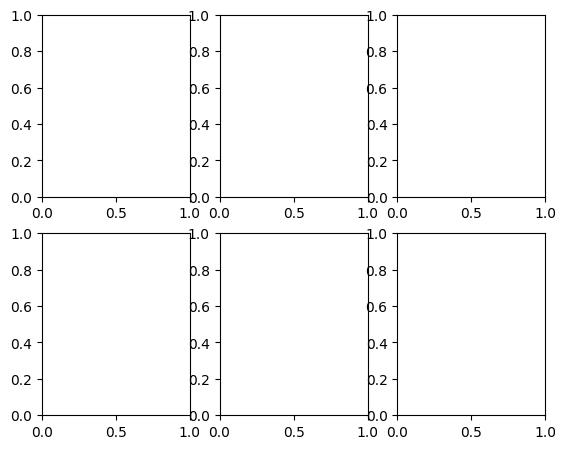

In [12]:
# --- Hardcoded Dates for the Analysis ---
dates_and_labels = [("2024-04-01", "Sunny Day"), ("2025-01-13", "Cloudy Day")]

# Create a combined figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(6.5, 5.2), sharey=False)
plot_handles = {}

for row_idx, (target_date, title_label) in enumerate(dates_and_labels):
    target_times = [
        pd.Timestamp(f"{target_date} 07:00"),
        pd.Timestamp(f"{target_date} 10:00"),
        pd.Timestamp(f"{target_date} 13:00"),
    ]
    actual_times = [
        t if t in test.index else t.floor("30min") for t in target_times
    ]

    for col_idx, target_time in enumerate(actual_times):
        ax = axes[row_idx, col_idx]

        # Get target values and vector features
        cf = test.loc[[target_time], feature_cols]
        cv = test.loc[target_time, "solar_kw"]

        preds_abs = []
        mae_vals = []
        for s, h in zip(steps, horizon_names):
            p_ramp = models[h].predict(cf)[0]
            preds_abs.append(np.clip(cv + p_ramp, 0, None))
            mae_vals.append(
                eval_xgb_df.loc[
                    eval_xgb_df["horizon"] == h, "mae_wm2"
                ].values[0]
                / 1000
            )

        future_times = [
            target_time + pd.Timedelta(minutes=int(h.replace("m", "")))
            for h in horizon_names
        ]
        plot_times = [target_time] + future_times
        y_preds = [cv] + preds_abs
        y_actuals = [cv] + [
            test.loc[t, "solar_kw"] if t in test.index else np.nan
            for t in future_times
        ]
        y_persist = [cv] * 7
        baseline = [cv] + [
            clim_lookup.get((t.hour, t.minute), 0) for t in future_times
        ]

        lower = [cv] + [max(0, p - m) for p, m in zip(preds_abs, mae_vals)]
        upper = [cv] + [p + m for p, m in zip(preds_abs, mae_vals)]
        history = test.loc[
            target_time - pd.Timedelta(hours=4) : target_time, "solar_kw"
        ]

        # --- Plot Elements ---
        h1 = ax.plot(
            history.index,
            history.values,
            color="#7f7f7f",
            ls="-",
            lw=1.1,
            alpha=0.7,
            label="History",
        )[0]
        h2 = ax.plot(
            plot_times,
            y_actuals,
            color="#2ca02c",
            ls=":",
            lw=1.8,
            label="Actual Ground Truth",
        )[0]
        h3 = ax.plot(
            plot_times,
            baseline,
            color="#1f77b4",
            ls="--",
            lw=1.2,
            label="Climatology",
        )[0]
        h4 = ax.plot(
            plot_times,
            y_persist,
            color="#ff7f0e",
            ls="-.",
            lw=1.2,
            label="Persistence",
        )[0]
        h5 = ax.fill_between(
            plot_times, lower, upper, color="#d62728", alpha=0.10, label="MAE Band"
        )
        h6 = ax.plot(
            plot_times,
            y_preds,
            color="#d62728",
            lw=1.8,
            marker="o",
            ms=4,
            mec="white",
            mew=0.6,
            label="XGBoost (Proposed)",
        )[0]

        ax.axvline(
            target_time, color="#d62728", alpha=0.35, ls="--", lw=0.8, zorder=1
        )

        for h in [h1, h2, h3, h4, h5, h6]:
            plot_handles[h.get_label()] = h

        # --- Formatting ---
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, linestyle=":", alpha=0.5, zorder=0)

        # Set individual column subtitle ("Origin: XX:XX")
        ax.set_title(f"Origin: {target_time.strftime('%H:%M')}", pad=4)

        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))

        # Dynamic ceiling tracking per panel
        all_curves = [history.values, y_actuals, baseline, y_persist, upper]
        max_val = np.nanmax([np.nanmax(c) for c in all_curves])
        ax.set_ylim(-0.02, max_val + 0.15)

    # Standard clean Y label on the first column of each row
    axes[row_idx, 0].set_ylabel("Solar Irradiance [kW/m²]", labelpad=6)

# Use tight_layout to handle subplot spacing comfortably before text positioning
plt.tight_layout(rect=[0, 0.06, 1, 0.98])

# --- Add Standalone Header Titles for Each Row ---
# Centered globally relative to the figure canvas using fig.text
fig.text(
    0.5, 0.96, "(a) Sunny Day — 2024-04-01", fontsize=11, fontweight="bold", ha="center"
)
fig.text(
    0.5, 0.49, "(b) Cloudy Day — 2025-01-13", fontsize=11, fontweight="bold", ha="center"
)

# Adjust spacing specifically to prevent the new headers from overlapping graphs
plt.subplots_adjust(top=0.91, hspace=0.45)

# Single shared global legend centered at the absolute bottom
fig.legend(
    handles=list(plot_handles.values()),
    labels=list(plot_handles.keys()),
    loc="lower center",
    bbox_to_anchor=(0.5, 0),
    ncol=3,
    frameon=True,
    edgecolor="#e0e0e0",
    fontsize=8,
)

# plt.savefig("combined_forecast_scenarios.pdf", dpi=300, bbox_inches='tight')
plt.show()

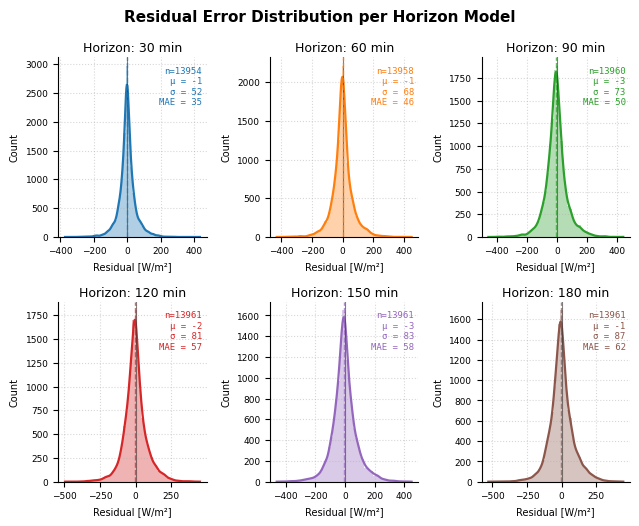

In [18]:
# --- Residual Error Distribution for Each Horizon Model (2×3 grid) ---
solar_vals = test["solar_kw"].values

# Compute residuals for all 6 horizon models on the full test set
residuals = {}
for s, h in zip(steps, horizon_names):
    target = f"target_solar_diff_{h}"
    pred_ramp = models[h].predict(test[feature_cols])
    pred_abs = np.clip(solar_vals + pred_ramp, 0, None)
    actual_abs = solar_vals + test[target].values
    mask = (~np.isnan(actual_abs)) & (actual_abs > 0.01)
    residual_wm2 = (actual_abs - pred_abs) * 1000  # convert to W/m²
    residuals[h] = residual_wm2[mask]

# Horizon display labels
horizon_labels = [f"{s*30} min" for s in steps]

# Color palette matching the established scheme
horizon_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

fig, axes = plt.subplots(2, 3, figsize=(6.5, 5.2))
axes_flat = axes.flatten()

for idx, (h, label) in enumerate(zip(horizon_names, horizon_labels)):
    ax = axes_flat[idx]
    res = residuals[h]
    n = len(res)

    # Histogram (counts, not density)
    counts, bins, _ = ax.hist(res, bins=60, density=False,
                              color=horizon_colors[idx],
                              alpha=0.35, edgecolor="none")

    # KDE scaled to match histogram area
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(res)
    x_grid = np.linspace(res.min(), res.max(), 300)
    bin_width = bins[1] - bins[0]
    kde_scaled = kde(x_grid) * n * bin_width
    ax.plot(x_grid, kde_scaled, color=horizon_colors[idx],
            lw=1.6, label="KDE (scaled)")

    # Zero line
    ax.axvline(0, color="#333333", ls="-", lw=0.8, alpha=0.6)

    # Mean line
    mean_res = np.mean(res)
    ax.axvline(mean_res, color=horizon_colors[idx], ls="--", lw=1.0, alpha=0.7)

    # Annotate stats
    std_res = np.std(res)
    ax.text(0.97, 0.95, f"n={n}\nμ = {mean_res:+.0f}\nσ = {std_res:.0f}\nMAE = {np.mean(np.abs(res)):.0f}",
            transform=ax.transAxes, fontsize=6.5, va="top", ha="right",
            color=horizon_colors[idx], fontfamily="monospace")

    # --- Formatting (matching existing style) ---
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, linestyle=":", alpha=0.5, zorder=0)
    ax.set_title(f"Horizon: {label}", pad=4, fontsize=9)
    ax.set_xlabel("Residual [W/m²]", fontsize=7)
    ax.set_ylabel("Count", fontsize=7)
    ax.tick_params(labelsize=6.5)

plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.text(0.5, 0.98, "Residual Error Distribution per Horizon Model",
         fontsize=11, fontweight="bold", ha="center")
# plt.savefig("residual_distribution_grid.pdf", dpi=300, bbox_inches="tight")
plt.show()
